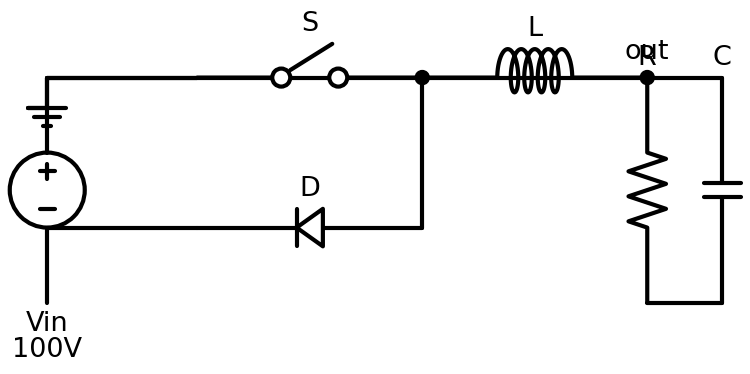

In [1]:
import schemdraw
import schemdraw.elements as elm
import matplotlib.pyplot as plt
from IPython.display import Image, display

with schemdraw.Drawing(show=False) as d:
    d.config(fontsize=13)
    Vin = d.add(elm.SourceV().up().label('Vin\n100V', loc='left'))
    d.add(elm.Line().right(2))
    d.add(elm.Switch().right().label('S', loc='top'))
    sw = d.add(elm.Dot())
    d.add(elm.Inductor2().right().label('L', loc='top'))
    d.add(elm.Dot().label('out', loc='top'))
    d.add(elm.Line().right(1))
    d.add(elm.Capacitor().down().label('C', loc='right'))
    d.add(elm.Line().left(1))
    d.add(elm.Resistor().up().label('R', loc='right'))
    d.add(elm.Line().left().tox(Vin.start))
    d.add(elm.Ground())
    d.add(elm.Line().at(sw.end).down(2))
    d.add(elm.Diode().left().label('D', loc='top'))
    d.add(elm.Line().left().tox(Vin.start))
    d.save('buck_ccm_1_fig.png', dpi=150)

display(Image('buck_ccm_1_fig.png', width=320))

In [2]:
%pycat buck_ccm_orig.cir

Buck Converter CCM
Vin in 0 DC $Vin
Vpwm gate 0 PULSE(0 5 0 1n 1n $TON $T)
S1 in sw gate 0 SWMOD
D1 0 sw DMOD
L1 sw out $L IC=0
C1 out 0 $C IC=0
RL out 0 $R
.MODEL SWMOD SW(Ron=0.01 Roff=1MEG Vt=2.5)
.MODEL DMOD D(Is=1n N=1 Rs=0.01)
.TRAN $TSTEP $TEND UIC
.SAVE $SAVE_VARS
.END


In [3]:
import ngspice_calc as calc

s_Vin = '100'
s_L = '0.6e-3'
s_C = '50e-6'
s_R = '2.5'
s_D = '0.4'
s_f_hz = '10e3'

D = float(s_D)
f_hz = float(s_f_hz)
T = 1.0 / f_hz
Ton = D * T
Tstep = T / 500
Tend = 50*T

l = [
    ('$Vin', s_Vin),
    ('$L', s_L),
    ('$C', s_C),
    ('$R', s_R),
    ('$TON', f'{Ton:.10f}'),
    ('$T', f'{T:.10f}'),
    ('$TSTEP', f'{Tstep:.10f}'),
    ('$TEND', f'{Tend:.6f}'),
    ('$SAVE_VARS', f'v(out) v(sw) i(l1) i(vin)')
]


calc.replace_strings_1('buck_ccm_orig.cir', 'buck_ccm.cir', l)
print("buck_ccm.cir is ready for use")

buck_ccm.cir is ready for use


In [4]:
print(open('buck_ccm.cir').read())

Buck Converter CCM
Vin in 0 DC 100
Vpwm gate 0 PULSE(0 5 0 1n 1n 0.0000400000 0.0001000000)
S1 in sw gate 0 SWMOD
D1 0 sw DMOD
L1 sw out 0.6e-3 IC=0
C1 out 0 50e-6 IC=0
RL out 0 2.5
.MODEL SWMOD SW(Ron=0.01 Roff=1MEG Vt=2.5)
.MODEL DMOD D(Is=1n N=1 Rs=0.01)
.TRAN 0.0000002000 0.005000 UIC
.SAVE v(out) v(sw) i(l1) i(vin)
.END


In [5]:
calc.run_ngspice('buck_ccm.cir')


Note: No compatibility mode selected!


Circuit: buck converter ccm

binary raw file "buck_ccm.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 5  
Operating point simulation skipped by 'uic',
  now using transient initial conditions.

No. of Data Rows : 27484

Total analysis time (seconds) = 0.0705823

Total elapsed time (seconds) = 0.076 

Total DRAM available = 15614.742 MB.
DRAM currently available = 3478.117 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.656 MB.

Shared ngspice pages =   10.879 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'buck_ccm.raw'

In [6]:
import numpy as np

s = calc.slv('buck_ccm.cir')
print("Variables: ", s.variables())

Variables:  ['time', 'v(out)', 'v(sw)', 'i(l1)', 'i(vin)']


In [7]:
t1 = s.get_array('time')
IL = s.get_array('i(l1)')
Vout = s.get_array('v(out)')
Vsw = s.get_array('v(sw)')
I_vin = s.get_array('i(vin)')

R = float(s_R)

IS = -I_vin            
ID = np.where(Vsw < 1.0, IL, 0.0)
I_load = Vout / R                
IC = IL - I_load             

t_start_ss = t1[-1] - 2 * T
t_end_ss = t1[-1]

l_IL = calc.avg_rms(t1, IL, t_start=t_start_ss, t_end=t_end_ss)
l_IS = calc.avg_rms(t1, IS, t_start=t_start_ss, t_end=t_end_ss)
l_ID = calc.avg_rms(t1, ID, t_start=t_start_ss, t_end=t_end_ss)
l_IC = calc.avg_rms(t1, IC, t_start=t_start_ss, t_end=t_end_ss)
l_v_out = calc.avg_rms(t1, Vout, t_start=t_start_ss, t_end=t_end_ss)

IL_min, IL_max = calc.min_max(t1, IL, t_start=t_start_ss, t_end=t_end_ss)
VC_min, VC_max = calc.min_max(t1, Vout, t_start=t_start_ss, t_end=t_end_ss)

IL_ptop = IL_max - IL_min
VC_ptop = VC_max - VC_min

print(f"average output voltage: {l_v_out[0]:11.4E}")
print(f"average inductor currnet: {l_IL[0]:11.4E}")
print(f"average switch current: {l_IS[0]:11.4E}")
print()

print(f'IL_ptop : {IL_ptop:11.4E}')
print(f'IL_peak : {IL_max:11.4E}')
print(f'VC_ptop : {VC_ptop:11.4E}')
print()
print(f'IL_rms  : {l_IL[1]:11.4E}')
print(f'IS_rms  : {l_IS[1]:11.4E}')
print(f'ID_rms  : {l_ID[1]:11.4E}')
print(f'IC_rms  : {l_IC[1]:11.4E}')
print(f'Vout_avg: {l_v_out[0]:11.4E}')

average output voltage:  3.9479E+01
average inductor currnet:  1.5792E+01
average switch current:  6.3169E+00

IL_ptop :  4.0510E+00
IL_peak :  1.7818E+01
VC_ptop :  1.0080E+00

IL_rms  :  1.5835E+01
IS_rms  :  1.0016E+01
ID_rms  :  1.2265E+01
IC_rms  :  1.1621E+00
Vout_avg:  3.9479E+01


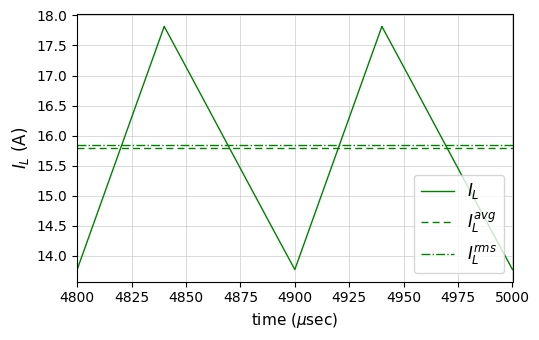

In [8]:

mask  = t1 >= t_start_ss
t_plt = t1[mask] * 1e6   # convert to microseconds
IL_plt = IL[mask]

color1 = 'green'
color2 = 'crimson'
color3 = 'goldenrod'
color4 = 'blue'

fig, ax = plt.subplots(figsize=(5.5, 3.5))
plt.subplots_adjust(wspace=0, hspace=0.0)
ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
ax.set_xlim(left=t_plt[0], right=t_plt[-1])

ax.plot(t_plt, IL_plt,    color=color1, linewidth=1.0, label=r'$I_L$')
ax.axhline(y=l_IL[0],    color=color1, linewidth=1.0, label=r'$I_L^{avg}$',
           linestyle='--', dashes=(5, 3))
ax.axhline(y=l_IL[1],    color=color1, linewidth=1.0, label=r'$I_L^{rms}$',
           linestyle='-.')

ax.set_xlabel(r'time ($\mu$sec)', fontsize=11)
ax.set_ylabel(r'$I_L$ (A)', fontsize=12)
ax.legend(loc='lower right', frameon=True, fontsize=10,
          markerfirst=True, markerscale=1.0, labelspacing=0.5,
          columnspacing=2.0, prop={'size': 12})

plt.tight_layout()
plt.show()